In [1]:
!pip install semopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.9 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=d9d80fab73a5e7ccddac2ad46e7bcfbc2ccb1c6a40a47b54d0d04c204d047853
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


In [2]:
import pandas as pd
from semopy import Model


In [3]:
from google.colab import files
uploaded=files.upload()

Saving student_performance.csv to student_performance.csv


In [4]:
df = pd.read_csv('/content/student_performance.csv')
print(df.shape)
df.head()


(14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [6]:
df.describe()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [7]:
# Step 3 Creat Model : Define the SEM Model
# Specify the relationships between observed and latent variables in the dataset.

model_desc = """
    # Measurement model
    FinalGrade =~ AssignmentCompletion + ExamScore + LearningStyle
    LearningStyle =~  OnlineCourses+ Discussions+Resources+StudyHours


    # Structural model
    FinalGrade =~ AssignmentCompletion + ExamScore + LearningStyle
    LearningStyle =~  OnlineCourses+ Discussions+Resources+StudyHours

"""

# Step 4 Fit the model based on the SEM model
model = Model(model_desc)

# Fit the model to the dataset
res = model.fit(df)

In [8]:
# Step 5: Evaluate the Model
# Inspect parameters and calculate goodness-of-fit metrics.

print("\nParameter Estimates:")
parameters = model.inspect()  # Inspect the parameter estimates
parameters


Parameter Estimates:


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,LearningStyle,~,FinalGrade,0.309956,0.1586,1.954333,0.050662
1,AssignmentCompletion,~,FinalGrade,1.000000,-,-,-
2,ExamScore,~,FinalGrade,15.091661,77.572161,0.19455,0.845745
3,OnlineCourses,~,LearningStyle,1.000000,-,-,-
4,Discussions,~,LearningStyle,0.000094,0.003458,0.027089,0.978389
5,Resources,~,LearningStyle,0.002091,0.029114,0.071808,0.942755
6,StudyHours,~,LearningStyle,-0.022138,0.306951,-0.072123,0.942504
7,FinalGrade,~~,FinalGrade,0.474737,2.447429,0.193974,0.846196
8,LearningStyle,~~,LearningStyle,7.793522,108.673133,0.071715,0.942829
9,AssignmentCompletion,~~,AssignmentCompletion,213.652177,3.532781,60.477048,0.0


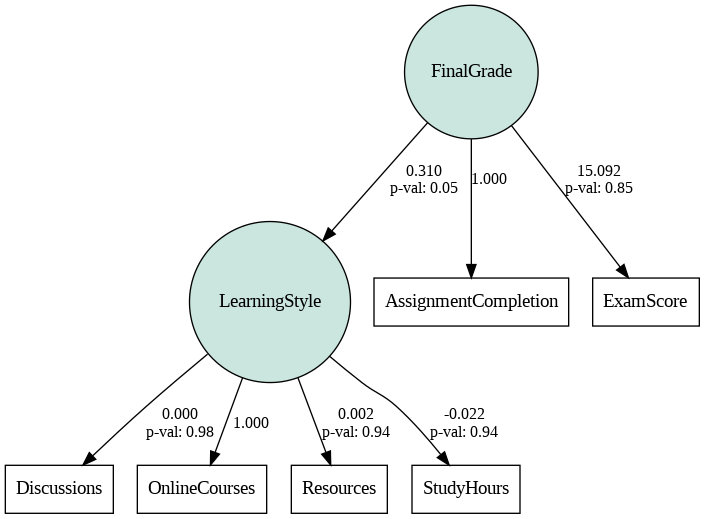

In [9]:
from semopy import semplot # Import the 'plot' function from semopy

from IPython.display import Image

# Assuming `model` is already defined and fitted

# Step 6: Visualize the SEM Model
# Save the visualization to a file and display it
semplot(model,"model.png")  # Use 'plot' instead of 'plot_sem' to save the diagram
Image(filename="model.png")  # Display the image inline in the notebook

In [20]:
from graphviz import Digraph

# Step 6: Visualize the SEM Model Using Graphviz
dot = Digraph(format='png', engine='dot')

# 1. Add nodes for your specific latent variables (Ovals)
dot.node("LearningStyle", "Learning Style", shape="ellipse")
dot.node("FinalGrade", "Final Grade", shape="ellipse")

# 2. Add nodes for observed variables (Rectangles)
# Let's assume x1-x5 are indicators for LearningStyle
# and x6-x9 are indicators for FinalGrade
observed_vars = [f"x{i}" for i in range(1, 10)]
for var in observed_vars:
    dot.node(var, var, shape="box")

# 3. Add edges for Measurement Model (Arrows from Latent to Observed)
# Adjust these pairings based on your actual survey/data structure
dot.edges([("LearningStyle", "x1"), ("LearningStyle", "x2"),
           ("LearningStyle", "x3"), ("LearningStyle", "x4"), ("LearningStyle", "x5")])

dot.edges([("FinalGrade", "x6"), ("FinalGrade", "x7"),
           ("FinalGrade", "x8"), ("FinalGrade", "x9")])

# 4. Add edges for Structural Model (The relationship between the two)
# This shows that Learning Style predicts or influences Final Grade
dot.edge("LearningStyle", "FinalGrade", label="Impact")

# Render the graph
dot.render("studentlearning_sem_model", view=True)

'studentlearning_sem_model.png'

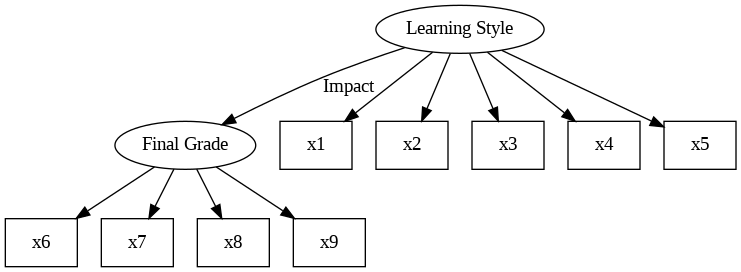

In [21]:
from IPython.display import Image
Image('studentlearning_sem_model.png')

In [12]:
# Step 7: Predict Latent Variables
# Extract predicted latent variable scores from the fitted SEM model.

latent_predictions = model.predict_factors(df)
print("\nPredicted Latent Variables:")
print(latent_predictions.head())


Predicted Latent Variables:
   FinalGrade  LearningStyle
0   -0.721276      -0.569901
1   -0.061213       1.260298
2    0.667772       2.065573
3   -0.721276      -0.569901
4   -0.061213       1.260298


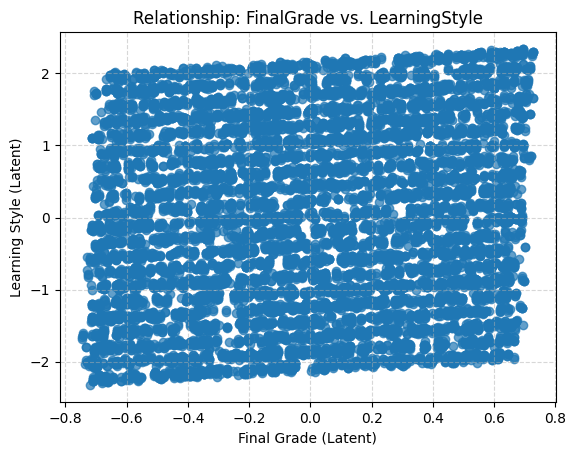

In [14]:
# Step 8: Visualize Relationships
# Create scatter plots to explore relationships between latent variables.
import matplotlib.pyplot as plt

# Scatter plot: FinalGrade vs. LearningStyle
plt.scatter(latent_predictions['FinalGrade'], latent_predictions['LearningStyle'], alpha=0.7)

# Update the visual details
plt.title("Relationship: FinalGrade vs. LearningStyle")
plt.xlabel("Final Grade (Latent)")
plt.ylabel("Learning Style (Latent)")

# Optional: Add a grid to make it easier to read
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [15]:
# Calculate the correlation coefficient
correlation = latent_predictions['FinalGrade'].corr(latent_predictions['LearningStyle'])

print(f"Correlation Coefficient: {correlation:.4f}")

# Interpretation logic
if abs(correlation) < 0.1:
    print("Interpretation: Negligible/No relationship")
elif abs(correlation) < 0.3:
    print("Interpretation: Weak relationship")
elif abs(correlation) < 0.5:
    print("Interpretation: Moderate relationship")
else:
    print("Interpretation: Strong relationship")

Correlation Coefficient: 0.1369
Interpretation: Weak relationship
